--- Dataset Preview ---
  ticker                    asset_name asset_type  stock_price  \
0    RTX  RTX Corporation Common Stock      Stock       100.99   
1    DHR                  Danaher Corp      Stock       249.80   
2     UL              Unilever Plc ADR      Stock        47.99   
3     IR            Ingersoll Rand Inc      Stock        93.48   
4    NVS               Novartis Ag ADR      Stock        95.81   

      transaction transaction_date  asset_value_low  asset_value_high  \
0     Sale (Full)       04/09/2024            15001             50000   
1     Sale (Full)       04/09/2024            15001             50000   
2     Sale (Full)       04/09/2024             1001             15000   
3     Sale (Full)       04/09/2024             1001             15000   
4  Sale (Partial)       04/09/2024             1001             15000   

    last_name first_name   owner additional_details  
0  Whitehouse    Sheldon  Spouse                 --  
1  Whitehouse    Sheldon  Spouse

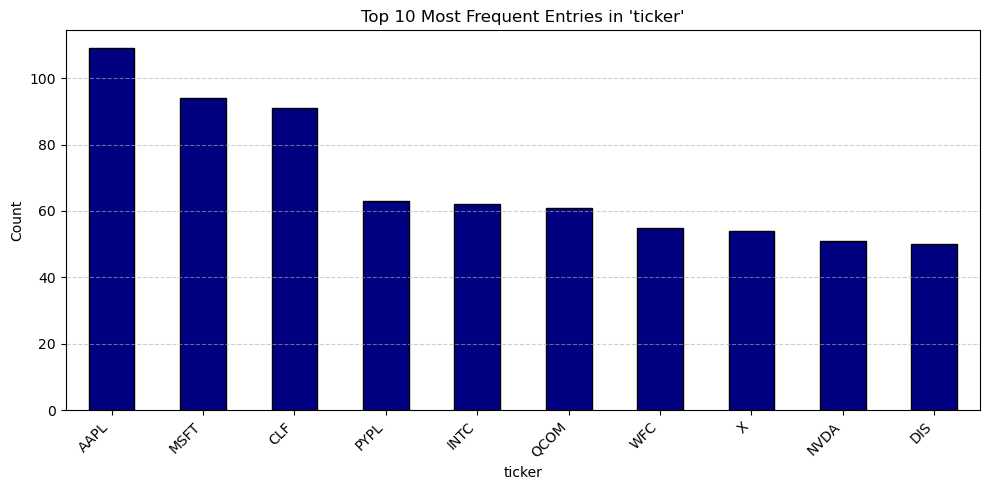

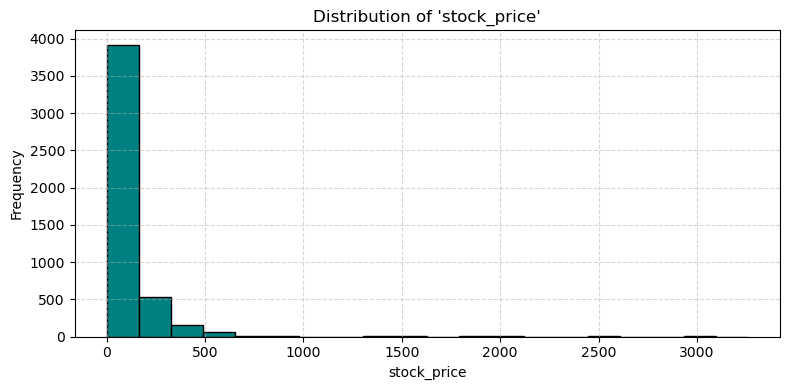

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset directly using your Windows path
df = pd.read_csv(r"C:\Users\AI_LAB\Downloads\archive\senate_stock_disclosures_cleaned.csv")

# 1. Dataset Overview & Schema
print("--- Dataset Preview ---")
print(df.head())

print("\n--- Dataset Info & Data Types ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 2. Categorical Analysis (Senators, Tickers, Transaction Types, etc.)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

print("\n--- Top Entries per Categorical Column ---")
for col in categorical_cols:
    print(f"\nTop 5 in '{col}':")
    print(df[col].value_counts().head(5))

# 3. Numerical Summary Statistics
numeric_cols = df.select_dtypes(include=["number"]).columns
if len(numeric_cols) > 0:
    print("\n--- Summary Statistics (Numeric) ---")
    print(df[numeric_cols].describe())

# 4. Data Visualizations
# Visual 1: Top 10 Frequency Chart for the Primary Categorical Column (e.g. Senator or Ticker)
if len(categorical_cols) > 0:
    target_cat = categorical_cols[0]
    plt.figure(figsize=(10, 5))
    df[target_cat].value_counts().head(10).plot(kind="bar", color="navy", edgecolor="black")
    plt.title(f"Top 10 Most Frequent Entries in '{target_cat}'")
    plt.xlabel(target_cat)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# Visual 2: Distribution of First Numeric Column (if present)
if len(numeric_cols) > 0:
    target_num = numeric_cols[0]
    plt.figure(figsize=(8, 4))
    df[target_num].hist(bins=20, color="teal", edgecolor="black")
    plt.title(f"Distribution of '{target_num}'")
    plt.xlabel(target_num)
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()